In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset directly from a reliable GitHub raw URL to avoid HTTP 403 errors
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


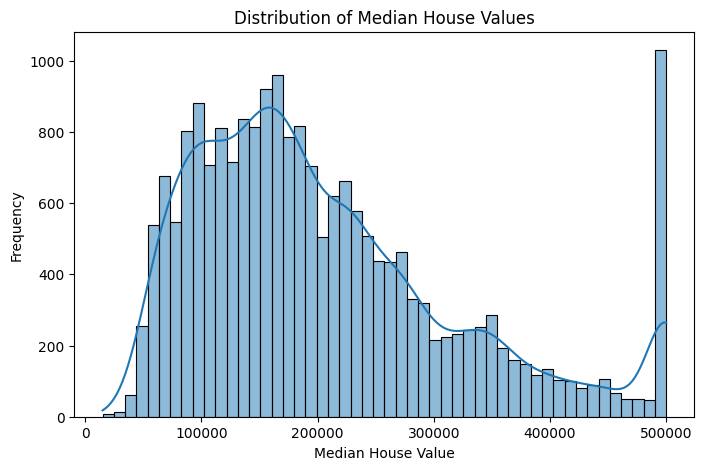

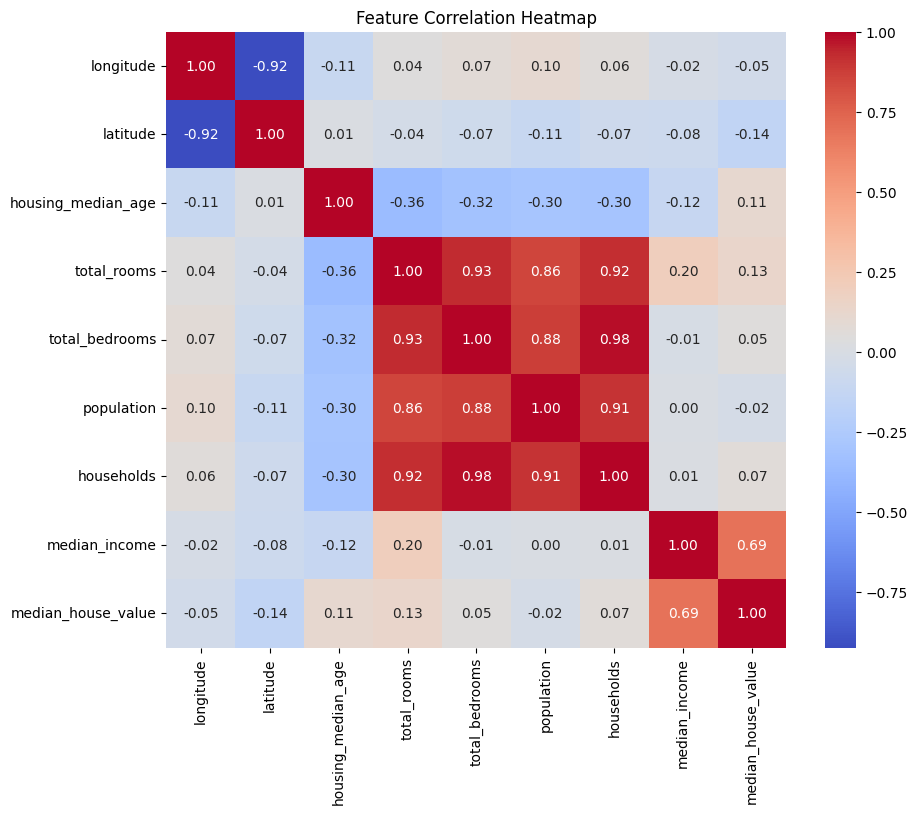

In [3]:
plt.figure(figsize=(8, 5))
# The target variable is now called 'median_house_value'
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

# Look at correlations to see which feature affects price the most
plt.figure(figsize=(10, 8))
# numeric_only=True is required now because we have a text column!
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. CLEANING: Handle missing values in 'total_bedrooms' by filling them with the median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# 2. ENCODING: One-Hot Encode the categorical 'ocean_proximity' text column
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# 80% Training, 20% Testing (No stratify needed for regression!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data cleaned, encoded, scaled, and split successfully!")

Data cleaned, encoded, scaled, and split successfully!


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Linear Regression Baseline
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_preds = lin_reg.predict(X_test_scaled)

print("--- Linear Regression ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lin_preds)):.4f}")
print(f"R2 Score: {r2_score(y_test, lin_preds):.4f}\n")

# 2. Random Forest Baseline
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_scaled, y_train)
rf_preds = rf_reg.predict(X_test_scaled)

print("--- Random Forest (Default) ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")
print(f"R2 Score: {r2_score(y_test, rf_preds):.4f}")

--- Linear Regression ---
RMSE: 70060.5218
R2 Score: 0.6254

--- Random Forest (Default) ---
RMSE: 49008.7892
R2 Score: 0.8167


In [6]:
from sklearn.model_selection import GridSearchCV

# We define a "grid" of settings we want to test
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [None, 10, 20],         # Maximum depth of each tree
    'min_samples_split': [2, 5]          # Minimum samples required to split an internal node
}

# Initialize a base model
base_rf = RandomForestRegressor(random_state=42)

# Set up the Grid Search (this runs Cross-Validation internally!)
grid_search = GridSearchCV(estimator=base_rf, param_grid=param_grid,
                           cv=3, scoring='neg_root_mean_squared_error',
                           verbose=2, n_jobs=-1)

# Fit it to the data (This will train 3 * 3 * 2 * 3(CV) = 54 different models! It takes a minute)
print("Starting Grid Search... This might take a minute.")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")

# Evaluate the winning model
best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test_scaled)

print("\n--- Optimized Random Forest ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, best_preds)):.4f}")
print(f"R2 Score: {r2_score(y_test, best_preds):.4f}")

Starting Grid Search... This might take a minute.
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Parameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

--- Optimized Random Forest ---
RMSE: 48809.9238
R2 Score: 0.8182
